In [7]:
import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import plotly.io as pio
pio.renderers.default = "iframe"

In [20]:
data = pd.read_csv("advertising.csv")

In [21]:
data.head(10)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


In [5]:
data.shape

(200, 4)

In [13]:
fig = px.scatter(data, x="TV", y="Sales")
fig.show()

In [15]:
fig = px.scatter(data, x="Radio", y="Sales")
fig.show()

In [16]:
fig = px.scatter(data, x="Newspaper", y="Sales")
fig.show()

In [88]:
df = data.copy()

X = df.drop(columns=["Sales"])
y = df.pop("Sales")

print(X.head())
print(y.head())

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [95]:
#fig = px.pie(train_X, title="advertising platforms")

#df_long = pd.melt(df, value_vars=['TV', 'Radio', 'Newspaper'], var_name='Ad campaign budgets', value_name='Budget_USD')

#fig = px.pie(df_long)

import plotly.graph_objects as go

fig = go.Figure(data=[go.Pie(
    labels=X.columns,          # Uses the column names directly
    values=X.iloc[0].values    # Uses the numbers from the first row
)])

fig.show()

In [80]:
model = LinearRegression()

In [81]:
model.fit(X, y)

print(model.coef_)
print(model.intercept_)

[0.05444578 0.10700123 0.00033566]
4.625124078808653


In [61]:
#X_line = np.linspace(train_X.min(), train_X.max(), 100).reshape(-1, 1)
#y_line_pred = model.predict(X_line)

#plt.plot(X_line, y_line_pred, color='k')
#plt.show()

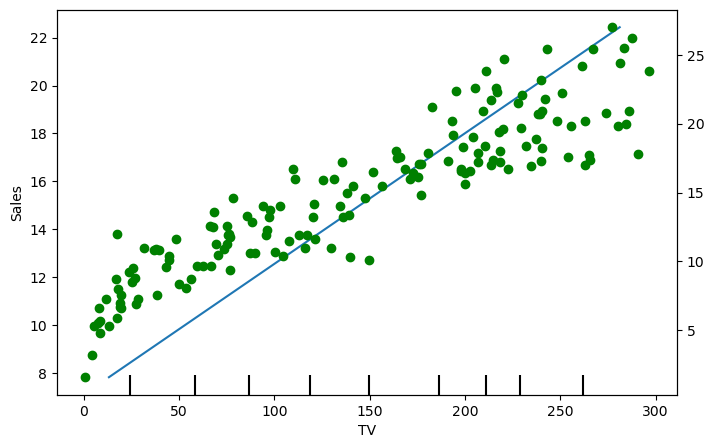

In [82]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[0], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

#ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["TV"], train_y, color='g')

plt.show()

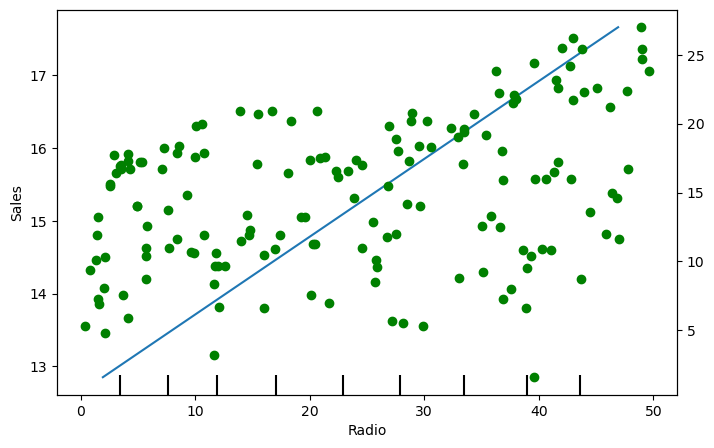

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[1], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["Radio"], train_y, color='g')

plt.show()

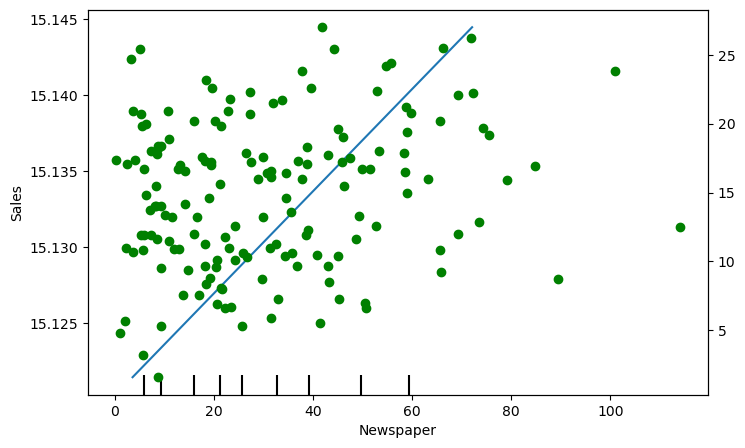

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))

display = PartialDependenceDisplay.from_estimator(model, X, features=[2], ax=ax)

for ax_row in display.axes_:
    for ax in ax_row:
        if ax.get_ylabel():  # Check if the axis has a y label enabled
            ax.set_ylabel("Sales")

ax2 = ax.twinx()
ax2.scatter(train_X["Newspaper"], train_y, color='g')

plt.show()

In [87]:
train_accuracy = model.score(train_X, train_y)
test_accuracy = model.score(test_X, test_y)

print(train_accuracy)
print(test_accuracy)

0.919533886383418
0.7995552679162206


In [65]:
predict_set = test_X.head(n=100)

print("predict set:\n\n", predict_set)

print("\ny_test:\n\n", test_y.head(n=100))

y_predicted = model.predict(predict_set)

print("\ny_predicted:\n\n", y_predicted)

predict set:

         TV  Radio  Newspaper
94   107.4   14.0       10.9
36   266.9   43.8        5.0
95   163.3   31.6       52.9
1     44.5   39.3       45.1
142  220.5   33.2       37.9
141  193.7   35.4       75.6
108   13.1    0.4       25.6
125   87.2   11.8       25.9
92   217.7   33.5       59.0
127   80.2    0.0        9.2
153  171.3   39.7       37.7
37    74.7   49.4       45.7
156   93.9   43.5       50.5
24    62.3   12.6       18.3
115   75.1   35.0       52.7
174  222.4    3.4       13.1
15   195.4   47.7       52.9
116  139.2   14.3       25.6
167  206.8    5.2       19.4
59   210.7   29.5        9.3
2     17.2   45.9       69.3
170   50.0   11.6       18.4
184  253.8   21.3       30.0
5      8.7   48.9       75.0
93   250.9   36.5       72.3
57   136.2   19.2       16.6
112  175.7   15.4        2.4
187  191.1   28.7       18.2
104  238.2   34.3        5.3
96   197.6    3.5        5.9
98   289.7   42.3       51.2
51   100.4    9.6        3.6
122  224.0    2.4       15.6

In [85]:
train_X.shape

(160, 3)

In [86]:
test_X.shape

(40, 3)